In [12]:
import pandas as pd
import numpy as np
from sklearn.linear_model import LinearRegression

# -------------------------------------------------
# Step 1: Load Data
# -------------------------------------------------
file_path = "/content/AEY Real(Charts Quarterly).csv"
df = pd.read_csv(file_path)

# Convert 'Close' column to numeric, coercing errors to NaN
df['Close'] = pd.to_numeric(df['Close'], errors='coerce')
# Drop rows where 'Close' is NaN (due to non-numeric values)
df.dropna(subset=['Close'], inplace=True)

y = df['Close'].values
x = np.arange(1, len(y) + 1)

# -------------------------------------------------
# Step 2: Create Polynomial Features (Normal)
# -------------------------------------------------
X = np.column_stack([x, x**2])   # Degree 2

# -------------------------------------------------
# Step 3: Fit Model
# -------------------------------------------------
model = LinearRegression()
model.fit(X, y)

# Coefficients
intercept = model.intercept_
beta1 = model.coef_[0]
beta2 = model.coef_[1]

# -------------------------------------------------
# Step 4: Predictions
# -------------------------------------------------
y_pred = model.predict(X)

# -------------------------------------------------
# Step 5: Compute ANOVA Values
# -------------------------------------------------
SST = np.sum((y - np.mean(y))**2)
SSE = np.sum((y - y_pred)**2)
SSR = SST - SSE
R_squared = SSR / SST

# -------------------------------------------------
# Step 6: Print Results (Like Your Screenshot)
# -------------------------------------------------
print("Standard Polynomial Coefficients:")
print("Intercept =", intercept)
print("x coefficient =", beta1)
print("x^2 coefficient =", beta2)

print("\nFinal Predicted Equation:")
print(f"ŷ = {intercept:.6f} + {beta1:.6f}x + {beta2:.6f}x²")

print("\nSST =", SST)
print("SSE =", SSE)
print("SSR =", SSR)

print("\nR-squared =", R_squared)

Standard Polynomial Coefficients:
Intercept = 2.8180525328330215
x coefficient = -0.03631309954934466
x^2 coefficient = 0.00016478841634825906

Final Predicted Equation:
ŷ = 2.818053 + -0.036313x + 0.000165x²

SST = 12.243639024390243
SSE = 7.2674906807203
SSR = 4.9761483436699425

R-squared = 0.4064272340728997


In [11]:
import pandas as pd
import numpy as np
from sklearn.linear_model import LinearRegression

# -------------------------------------------------
# Step 1: Load Data
# -------------------------------------------------
file_path = "/content/AEY Real(Charts Quarterly).csv"
df = pd.read_csv(file_path)

# Convert 'Close' column to numeric, coercing errors to NaN
df['Close'] = pd.to_numeric(df['Close'], errors='coerce')
# Drop rows where 'Close' is NaN (due to non-numeric values)
df.dropna(subset=['Close'], inplace=True)

y = df['Close'].values
x = np.arange(1, len(y) + 1)

n = len(y)

print("Number of observations (n):", n)

# -------------------------------------------------
# Step 2: Polynomial Features (Degree 2)
# -------------------------------------------------
X = np.column_stack([x, x**2])

# -------------------------------------------------
# Step 3: Fit Model
# -------------------------------------------------
model = LinearRegression()
model.fit(X, y)
y_pred = model.predict(X)

# -------------------------------------------------
# Step 4: ANOVA Calculations
# -------------------------------------------------
SST = np.sum((y - np.mean(y))**2)
SSE = np.sum((y - y_pred)**2)
SSR = SST - SSE

# Degrees of Freedom (Correct Formula)
k = X.shape[1]          # number of predictors (2 for quadratic)

df_reg = k              # 2
df_total = n - 1        # 40 (since n = 41)
df_res = df_total - df_reg   # 38

# Mean Squares
MS_reg = SSR / df_reg
MS_res = SSE / df_res

# F Statistic
F_stat = MS_reg / MS_res

# -------------------------------------------------
# Step 5: Print ANOVA Table
# -------------------------------------------------
print("\nANOVA TABLE")
print("------------------------------------------------------------")
print(f"{'Source':<12}{'DF':<8}{'SS':<15}{'MS':<15}{'F':<10}")
print("------------------------------------------------------------")
print(f"{'Regression':<12}{df_reg:<8}{SSR:<15.6f}{MS_reg:<15.6f}{F_stat:<10.6f}")
print(f"{'Residual':<12}{df_res:<8}{SSE:<15.6f}{MS_res:<15.6f}")
print(f"{'Total':<12}{df_total:<8}{SST:<15.6f}")
print("------------------------------------------------------------")

Number of observations (n): 41

ANOVA TABLE
------------------------------------------------------------
Source      DF      SS             MS             F         
------------------------------------------------------------
Regression  2       4.976148       2.488074       13.009555 
Residual    38      7.267491       0.191250       
Total       40      12.243639      
------------------------------------------------------------


In [14]:
import pandas as pd
import numpy as np
from sklearn.linear_model import LinearRegression
from scipy.stats import f

# -------------------------------------------------
# Step 1: Load Data
# -------------------------------------------------
file_path = "/content/AEY Real(Charts Quarterly).csv"
df = pd.read_csv(file_path)

# Convert 'Close' column to numeric, coercing errors to NaN
df['Close'] = pd.to_numeric(df['Close'], errors='coerce')
# Drop rows where 'Close' is NaN (due to non-numeric values)
df.dropna(subset=['Close'], inplace=True)

y = df['Close'].values
x = np.arange(1, len(y) + 1)

n = len(y)

# -------------------------------------------------
# Step 2: Create Polynomial Features (Degree 2)
# -------------------------------------------------
X = np.column_stack([x, x**2])

# -------------------------------------------------
# Step 3: Fit Model
# -------------------------------------------------
model = LinearRegression()
model.fit(X, y)
y_pred = model.predict(X)

# -------------------------------------------------
# Step 4: ANOVA Components
# -------------------------------------------------
SST = np.sum((y - np.mean(y))**2)
SSE = np.sum((y - y_pred)**2)
SSR = SST - SSE

k = X.shape[1]          # number of predictors (2)

df_reg = k
df_total = n - 1
df_res = df_total - df_reg

MS_reg = SSR / df_reg
MS_res = SSE / df_res

F_stat = MS_reg / MS_res

# -------------------------------------------------
# Step 5: Compute p-value
# -------------------------------------------------
p_value = 1 - f.cdf(F_stat, df_reg, df_res)

alpha = 0.05

# -------------------------------------------------
# Step 6: Print Results (Like Your Screenshot)
# -------------------------------------------------
print("\nSignificance Test")
print("--------------------------")
print("F-statistic =", F_stat)
print("Degrees of Freedom =", df_reg, "and", df_res)
print("p-value =", p_value)
print("Significance level (alpha) =", alpha)

# Decision
if p_value < alpha:
    print("\nDecision: Reject H0")
    print("Conclusion: The quadratic model is statistically significant.")
else:
    print("\nDecision: Fail to Reject H0")
    print("Conclusion: The model is NOT statistically significant.")


Significance Test
--------------------------
F-statistic = 13.009554835832018
Degrees of Freedom = 2 and 38
p-value = 4.965984565108439e-05
Significance level (alpha) = 0.05

Decision: Reject H0
Conclusion: The quadratic model is statistically significant.


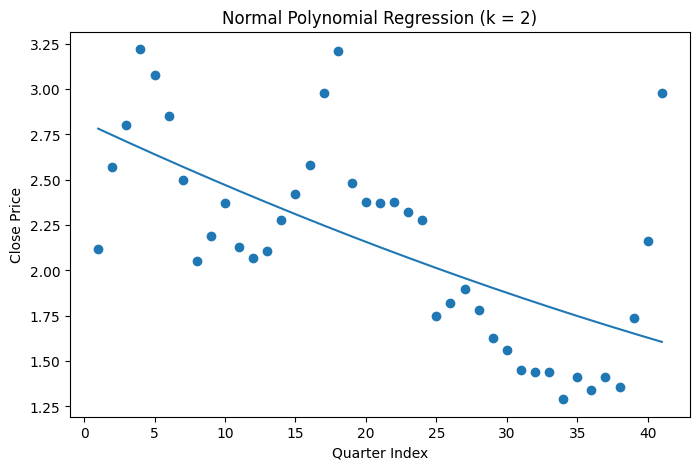

In [21]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression

# -------------------------------------------------
# Step 1: Load Data
# -------------------------------------------------
file_path = "/content/AEY Real(Charts Quarterly).csv"   # Corrected file path
df = pd.read_csv(file_path)  # Changed to read_csv

# Convert 'Close' column to numeric, coercing errors to NaN
df['Close'] = pd.to_numeric(df['Close'], errors='coerce')
# Drop rows where 'Close' is NaN (due to non-numeric values)
df.dropna(subset=['Close'], inplace=True)

y = df['Close'].values
x = np.arange(1, len(y) + 1)

# Reshape for sklearn
X = np.column_stack([x, x**2])

# -------------------------------------------------
# Step 2: Fit Quadratic Model (k = 2)
# -------------------------------------------------
model = LinearRegression()
model.fit(X, y)

# -------------------------------------------------
# Step 3: Create Smooth Curve
# -------------------------------------------------
x_fine = np.linspace(min(x), max(x), 300)
X_fine = np.column_stack([x_fine, x_fine**2])

y_fitted = model.predict(X_fine)

# -------------------------------------------------
# Step 4: Plot
# -------------------------------------------------
plt.figure(figsize=(8,5))

plt.scatter(x, y)
plt.plot(x_fine, y_fitted)

plt.title("Normal Polynomial Regression (k = 2)")
plt.xlabel("Quarter Index")
plt.ylabel("Close Price")

plt.show()

In [16]:
import pandas as pd
import numpy as np
from sklearn.linear_model import LinearRegression

# -------------------------------------------------
# Step 1: Load Data
# -------------------------------------------------
file_path = "/content/AEY Real(Charts Quarterly).csv"   # or your CSV file
df = pd.read_csv(file_path)

# Convert 'Close' column to numeric, coercing errors to NaN
df['Close'] = pd.to_numeric(df['Close'], errors='coerce')
# Drop rows where 'Close' is NaN (due to non-numeric values)
df.dropna(subset=['Close'], inplace=True)

y = df['Close'].values
x = np.arange(1, len(y) + 1)

# -------------------------------------------------
# Step 2: Create Cubic Features (k = 3)
# -------------------------------------------------
X = np.column_stack([x, x**2, x**3])

# -------------------------------------------------
# Step 3: Fit Model
# -------------------------------------------------
model = LinearRegression()
model.fit(X, y)

intercept = model.intercept_
beta1 = model.coef_[0]
beta2 = model.coef_[1]
beta3 = model.coef_[2]

y_pred = model.predict(X)

# -------------------------------------------------
# Step 4: Compute SST, SSE, SSR, R²
# -------------------------------------------------
SST = np.sum((y - np.mean(y))**2)
SSE = np.sum((y - y_pred)**2)
SSR = SST - SSE
R_squared = SSR / SST

# -------------------------------------------------
# Step 5: Print Output Like Your Screenshot
# -------------------------------------------------
print("\nStandard Polynomial Coefficients:")
print("Intercept =", intercept)
print("x coefficient =", beta1)
print("x^2 coefficient =", beta2)
print("x^3 coefficient =", beta3)

print("\nFinal Predicted Equation:")
print(f"ŷ = {intercept:.6f} + {beta1:.6f}x + {beta2:.6f}x² + {beta3:.6f}x³")

print("\nSST =", SST)
print("SSE =", SSE)
print("SSR =", SSR)

print("\nR-squared =", R_squared)


Standard Polynomial Coefficients:
Intercept = 2.2238135676903243
x coefficient = 0.12389750637556406
x^2 coefficient = -0.009257605322700632
x^3 coefficient = 0.00014956180538172777

Final Predicted Equation:
ŷ = 2.223814 + 0.123898x + -0.009258x² + 0.000150x³

SST = 12.243639024390243
SSE = 5.724562040130214
SSR = 6.519076984260028

R-squared = 0.5324460294258545


In [18]:
import pandas as pd
import numpy as np
from sklearn.linear_model import LinearRegression

# -------------------------------------------------
# Load Data
# -------------------------------------------------
file_path = "/content/AEY Real(Charts Quarterly).csv"
df = pd.read_csv(file_path)

# Convert 'Close' column to numeric, coercing errors to NaN
df['Close'] = pd.to_numeric(df['Close'], errors='coerce')
# Drop rows where 'Close' is NaN (due to non-numeric values)
df.dropna(subset=['Close'], inplace=True)

y = df['Close'].values
x = np.arange(1, len(y) + 1)

n = len(y)

# -------------------------------------------------
# Cubic Model (k = 3)
# -------------------------------------------------
X = np.column_stack([x, x**2, x**3])

model = LinearRegression()
model.fit(X, y)

y_pred = model.predict(X)

# -------------------------------------------------
# ANOVA Calculations
# -------------------------------------------------
SST = np.sum((y - np.mean(y))**2)
SSE = np.sum((y - y_pred)**2)
SSR = SST - SSE

k = 3

df_reg = k
df_total = n - 1
df_res = df_total - df_reg

MS_reg = SSR / df_reg
MS_res = SSE / df_res

F_stat = MS_reg / MS_res

# -------------------------------------------------
# PRINT ANOVA TABLE (Exactly Like Your Screenshot)
# -------------------------------------------------

print("\nANOVA TABLE")
print("------------------------------------------------------------")
print(f"{'Source':<12}{'DF':<8}{'SS':<15}{'MS':<15}{'F':<10}")
print("------------------------------------------------------------")
print(f"{'Regression':<12}{df_reg:<8}{SSR:<15.6f}{MS_reg:<15.6f}{F_stat:<10.6f}")
print(f"{'Residual':<12}{df_res:<8}{SSE:<15.6f}{MS_res:<15.6f}")
print(f"{'Total':<12}{df_total:<8}{SST:<15.6f}")
print("------------------------------------------------------------")


ANOVA TABLE
------------------------------------------------------------
Source      DF      SS             MS             F         
------------------------------------------------------------
Regression  3       6.519077       2.173026       14.045083 
Residual    37      5.724562       0.154718       
Total       40      12.243639      
------------------------------------------------------------


In [19]:
from scipy.stats import f

# -------------------------------------------------
# Degrees of freedom for k = 3
# -------------------------------------------------
k = 3
df_reg = k
df_res = 41 - (k + 1)   # 41 observations, 4 parameters
alpha = 0.05

# -------------------------------------------------
# Compute p-value
# -------------------------------------------------
p_value = 1 - f.cdf(F_stat, df_reg, df_res)

# -------------------------------------------------
# Print Output Like Your Screenshot
# -------------------------------------------------
print("\nSignificance Test")
print("--------------------------")
print(f"F-statistic = {F_stat}")
print(f"Degrees of Freedom = {df_reg} and {df_res}")
print(f"p-value = {p_value}")
print(f"Significance level (alpha) = {alpha}")

if p_value < alpha:
    print("\nDecision: Reject H0")
    print("Conclusion: The cubic model is statistically significant.")
else:
    print("\nDecision: Fail to Reject H0")
    print("Conclusion: The model is NOT statistically significant.")



Significance Test
--------------------------
F-statistic = 14.045083083895005
Degrees of Freedom = 3 and 37
p-value = 2.8786615590137288e-06
Significance level (alpha) = 0.05

Decision: Reject H0
Conclusion: The cubic model is statistically significant.


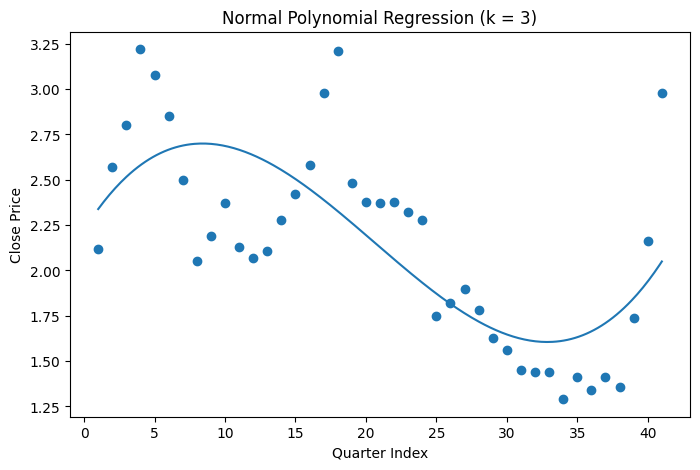

In [23]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression

# -------------------------------------------------
# Step 1: Load Data
# -------------------------------------------------
file_path = "/content/AEY Real(Charts Quarterly).csv"   # Corrected file path
df = pd.read_csv(file_path)  # Changed to read_csv

# Convert 'Close' column to numeric, coercing errors to NaN
df['Close'] = pd.to_numeric(df['Close'], errors='coerce')
# Drop rows where 'Close' is NaN (due to non-numeric values)
df.dropna(subset=['Close'], inplace=True)

y = df['Close'].values
x = np.arange(1, len(y) + 1)

# -------------------------------------------------
# Step 2: Create Cubic Features (k = 3)
# -------------------------------------------------
X = np.column_stack([x, x**2, x**3])

model = LinearRegression()
model.fit(X, y)

# -------------------------------------------------
# Step 3: Smooth Curve for Plotting
# -------------------------------------------------
x_fine = np.linspace(min(x), max(x), 300)
X_fine = np.column_stack([x_fine, x_fine**2, x_fine**3])

y_fitted = model.predict(X_fine)

# -------------------------------------------------
# Step 4: Plot
# -------------------------------------------------
plt.figure(figsize=(8,5))

plt.scatter(x, y)
plt.plot(x_fine, y_fitted)

plt.title("Normal Polynomial Regression (k = 3)")
plt.xlabel("Quarter Index")
plt.ylabel("Close Price")

plt.show()

In [25]:
import pandas as pd
import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

# -------------------------------------------------
# Load Data
# -------------------------------------------------
file_path = "/content/AEY Real(Charts Quarterly).csv"  # Corrected to CSV file path
df = pd.read_csv(file_path)

# Convert 'Close' column to numeric, coercing errors to NaN
df['Close'] = pd.to_numeric(df['Close'], errors='coerce')
# Drop rows where 'Close' is NaN (due to non-numeric values)
df.dropna(subset=['Close'], inplace=True)

y = df['Close'].values
x = np.arange(1, len(y) + 1)

n = len(y)

# -------------------------------------------------
# Function to compute metrics
# -------------------------------------------------
def compute_metrics(y, y_pred, k):

    # RMSE
    rmse = np.sqrt(np.mean((y - y_pred)**2))

    # MAPE
    mape = np.mean(np.abs((y - y_pred) / y)) * 100

    # R^2
    r2 = r2_score(y, y_pred)

    # Adjusted R^2
    adj_r2 = 1 - ((1 - r2) * (n - 1) / (n - k - 1))

    return rmse, mape, r2, adj_r2


# -------------------------------------------------
# Quadratic Model (k = 2)
# -------------------------------------------------
X_quad = np.column_stack([x, x**2])
model_quad = LinearRegression()
model_quad.fit(X_quad, y)

y_quad_pred = model_quad.predict(X_quad)

rmse_q, mape_q, r2_q, adj_r2_q = compute_metrics(y, y_quad_pred, k=2)


# -------------------------------------------------
# Cubic Model (k = 3)
# -------------------------------------------------
X_cubic = np.column_stack([x, x**2, x**3])
model_cubic = LinearRegression()
model_cubic.fit(X_cubic, y)

y_cubic_pred = model_cubic.predict(X_cubic)

rmse_c, mape_c, r2_c, adj_r2_c = compute_metrics(y, y_cubic_pred, k=3)


# -------------------------------------------------
# Print Results Like Your Table
# -------------------------------------------------
print("\nPolynomial Regression Results\n")

print(f"{'Model':<12}{'RMSE':<12}{'MAPE':<12}{'R^2':<12}{'Adj R^2':<12}")
print("-"*60)

print(f"{'Quadratic':<12}{rmse_q:<12.4f}{mape_q:<12.4f}{r2_q:<12.4f}{adj_r2_q:<12.4f}")
print(f"{'Cubic':<12}{rmse_c:<12.4f}{mape_c:<12.4f}{r2_c:<12.4f}{adj_r2_c:<12.4f}")


Polynomial Regression Results

Model       RMSE        MAPE        R^2         Adj R^2     
------------------------------------------------------------
Quadratic   0.4210      16.3432     0.4064      0.3752      
Cubic       0.3737      14.1702     0.5324      0.4945      


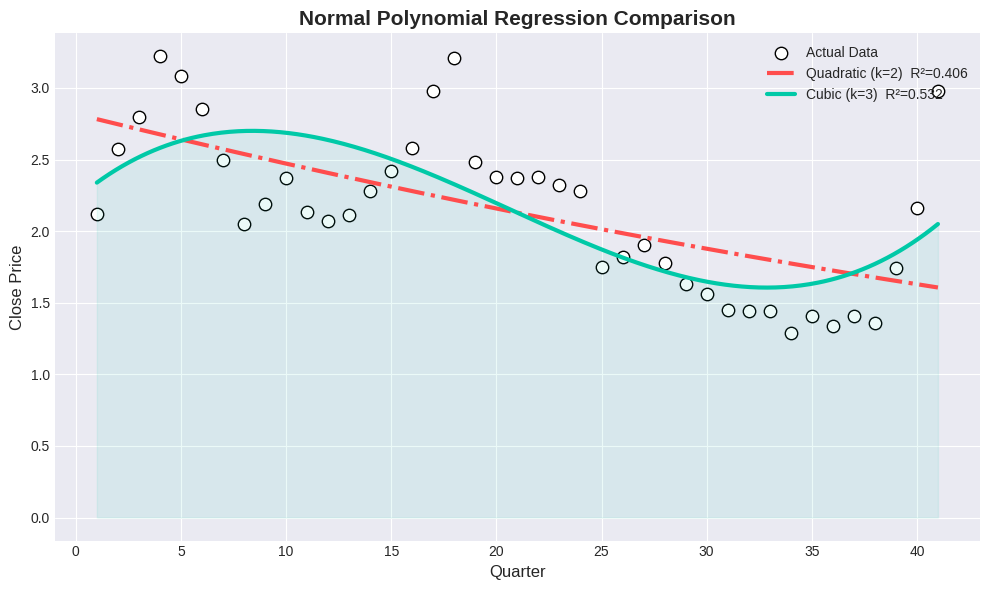

In [27]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

# -------------------------------------------------
# Load Data
# -------------------------------------------------
df = pd.read_csv("/content/AEY Real(Charts Quarterly).csv")

# Convert 'Close' column to numeric, coercing errors to NaN
df['Close'] = pd.to_numeric(df['Close'], errors='coerce')
# Drop rows where 'Close' is NaN (due to non-numeric values)
df.dropna(subset=['Close'], inplace=True)

y = df['Close'].values
x = np.arange(1, len(y) + 1)

# -------------------------------------------------
# Fit Quadratic (k=2)
# -------------------------------------------------
X_quad = np.column_stack([x, x**2])
model_quad = LinearRegression()
model_quad.fit(X_quad, y)

y_quad = model_quad.predict(X_quad)
r2_quad = r2_score(y, y_quad)

# -------------------------------------------------
# Fit Cubic (k=3)
# -------------------------------------------------
X_cubic = np.column_stack([x, x**2, x**3])
model_cubic = LinearRegression()
model_cubic.fit(X_cubic, y)

y_cubic = model_cubic.predict(X_cubic)
r2_cubic = r2_score(y, y_cubic)

# -------------------------------------------------
# Smooth Curves
# -------------------------------------------------
x_fine = np.linspace(min(x), max(x), 400)

X_quad_fine = np.column_stack([x_fine, x_fine**2])
X_cubic_fine = np.column_stack([x_fine, x_fine**2, x_fine**3])

y_quad_fine = model_quad.predict(X_quad_fine)
y_cubic_fine = model_cubic.predict(X_cubic_fine)

# -------------------------------------------------
# Unique Stylish Plot
# -------------------------------------------------
plt.figure(figsize=(10,6))

# Darker background for uniqueness
plt.style.use("seaborn-v0_8-darkgrid")

# Scatter
plt.scatter(x, y,
            color="white",
            edgecolor="black",
            s=80,
            label="Actual Data")

# Quadratic curve
plt.plot(x_fine, y_quad_fine,
         color="#ff4d4d",
         linewidth=3,
         linestyle="dashdot",
         label=f"Quadratic (k=2)  R²={r2_quad:.3f}")

# Cubic curve
plt.plot(x_fine, y_cubic_fine,
         color="#00c9a7",
         linewidth=3,
         linestyle="-",
         label=f"Cubic (k=3)  R²={r2_cubic:.3f}")

# Fill under cubic slightly for visual uniqueness
plt.fill_between(x_fine, y_cubic_fine,
                 color="#00c9a7",
                 alpha=0.08)

plt.title("Normal Polynomial Regression Comparison",
          fontsize=15,
          fontweight="bold")

plt.xlabel("Quarter", fontsize=12)
plt.ylabel("Close Price", fontsize=12)

plt.legend(fontsize=10)
plt.tight_layout()
plt.show()